<a href="https://colab.research.google.com/github/arielganoe/STAT-7220-Applied-Experimental-Design/blob/main/Copy_of_STAT_7110_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Homework 2 - Phase I & II Analysis Using CUSUM and EWMA Control Charts
### Dr. Austin Brown
### Kennesaw State University

**DUE: October 10, 2026 via D2L**

## Instructions:

Buster's Sports Bar & Grill runs a busy draft beer program, pouring a house lager through a long-draw, CO2-driven tap system. State regulations require that a pint be poured within a fairly tight volume tolerance, and management has its own reasons to care about consistency too: an overpour on every pint adds up to real lost profit over a month, while a noticeable underpour draws customer complaints and bad reviews. The general manager has asked your quality control team to investigate the pour consistency at the bar's main tap station.

Pours are measured directly from the tap using a calibrated in-line flow meter, in ounces. The general manager has flagged a specific concern: as a CO2 regulator ages, line pressure can creep downward very gradually over weeks or months, producing more foam and a slightly smaller liquid pour -- a small, **sustained** drift, rather than a sudden jump. A chart that's only good at catching a sudden shift could easily miss this kind of slow creep until it's been happening for a long time. Pour volume is treated as a continuous, normally-distributed quality characteristic for this assignment.

Your team pulls a baseline (Phase I) sample of pour data from the tap right after a fresh regulator was installed: 5 pints sampled at random each shift, for 25 consecutive shifts. After validating statistical control, the team designs an appropriate CUSUM and EWMA monitoring scheme and applies it to 20 additional shifts of data (Phase II), collected several months later, to determine whether the aging regulator is already producing a detectable drift.

## Key Specifications

| Quantity | Value |
|---|---|
| Target pour volume | 16.00 oz |
| Lower Specification Limit (LSL) | 15.80 oz |
| Upper Specification Limit (USL) | 16.20 oz |
| Subgroup size (n) | 5 pints per shift |
| Phase I subgroups (m) | 25 shifts |
| Phase II subgroups (m) | 20 shifts |

## Define & Measure

### Q1: Briefly describe the purpose of this analysis

The purpose of this analysis is to determine whether an aging CO2 regulator is causing a gradual decrease in draft beer. A phase 1 dataset of 25 shifts with 5 pours measured per shift. Phase II data consisting of 20 additional shifts collected several months later, are analyzed to detect any statistically significant downward trend in pour volume to understand the customer satisfaction or dissatisfaction of profit.  

Q2: Identify the quality characteristic your team will monitor, and classify its units and measurement scale.


The QC is volume, measured in ounces (oz) which is a continuous random variable measured on a ratio scale.

Q3: Briefly describe why a CUSUM and EWMA chart would be appropriate in this scenario, given the general manager's specific concern about the aging CO2 regulator. What are the limitations of these charts? Analyze

CUSUM and EWMA charts are appropriate because it detects the decrease in pour volume that may occur as CO2 ages and the pressure slowly declines. Unlike traditional control charts, they use information from previous samples to idenity sustained trends earlier. the limitations of the charts are stable process, and hard to understand and the assumptions might not be correct.

Q4: Read the Phase I data into R. Calculate and report the subgroup means and ranges, and use them to estimate the process mean and process standard deviation.

In [ ]:
%load_ext rpy2.ipython

In [ ]:
%%R
library(tidyverse)
library(readxl)
library(qcc)

## Read in Data ##

p1 <- read_xlsx("BustersSportsBar_PhaseI.xlsx")

p1 |>
  glimpse()

## Calculate Subgroup Means and Ranges ##

subgroup_means <- p1 |>
  select(-Shift) |>
  apply(1, mean)

subgroup_ranges <- p1 |>
  select(-Shift) |>
  apply(1, function(x) max(x) - min(x))

## Estimate Phase I Process Mean & SD using R & s methods ##

## R Method ##

sd_r <- qcc::sd.xbar(
  p1 |> select(-Shift),
  std.dev = "UWAVE-R"
)

## s Method ##

sd_s <- qcc::sd.xbar(
  p1 |> select(-Shift),
  std.dev = "UWAVE-SD"
)

## Overall Mean ##

xdbar <- mean(subgroup_means)

## Output Results ##

cat("Subgroup Means:\n")
print(round(subgroup_means, 4))

cat("\nSubgroup Ranges:\n")
print(round(subgroup_ranges, 4))

cat("\nOverall Mean:\n")
print(round(xdbar, 4))

cat("\nStandard Deviation (R Method):\n")
print(round(sd_r, 4))

cat("\nStandard Deviation (s Method):\n")
print(round(sd_s, 4))


Rows: 25
Columns: 6
$ Shift <dbl> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 1…
$ Pour1 <dbl> 16.0413, 16.0675, 16.0556, 16.0424, 15.9992, 16.0585, 16.1422, 1…
$ Pour2 <dbl> 16.1330, 16.0046, 15.9970, 16.1595, 15.9692, 16.1351, 16.1080, 1…
$ Pour3 <dbl> 16.2208, 16.0829, 16.0578, 16.1260, 16.0182, 15.9698, 16.0274, 1…
$ Pour4 <dbl> 15.9739, 16.0750, 16.0771, 15.9804, 15.9541, 15.9335, 15.9874, 1…
$ Pour5 <dbl> 16.0762, 16.0499, 16.0694, 16.0306, 15.9968, 16.0919, 16.0022, 1…
Subgroup Means:
 [1] 16.0890 16.0560 16.0514 16.0678 15.9875 16.0378 16.0534 16.0952 16.0668
[10] 16.0482 16.0458 15.7078 16.0786 16.0621 16.0064 16.0415 16.0551 16.0831
[19] 15.9957 16.0205 16.1008 16.0255 16.0923 16.0351 16.0605

Subgroup Ranges:
 [1] 0.2469 0.0783 0.0801 0.1791 0.0641 0.2016 0.1548 0.2202 0.1927 0.0942
[11] 0.1200 0.2178 0.1995 0.1993 0.1643 0.1941 0.1180 0.1488 0.6818 0.0912
[21] 0.0724 0.1377 0.2165 0.2231 0.1919

Overall Mean:
[1] 16.0386

Standard Deviation (R Method):
[1

### Q5: Construct a Phase I $R$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

We do have evidence of out-of-control conditions.
The following subgroup(s) plotted beyond the control limits: 19

Assuming an assignable cause is identified, we will omit these subgroup(s) and replot the Phase I R chart.


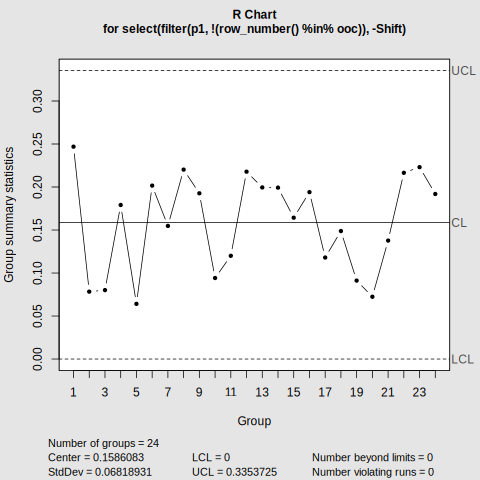

In [ ]:
%%R
## Q5 Code ##

## Phase 1 R chart ##
p1_r1 <- qcc(
  p1 |> select(-Shift),
  type = "R",
  plot = TRUE
)

# Check if we have Out-of-Control (OOC) points
if(length(p1_r1$violations$beyond.limits) > 0) {
  ooc <- p1_r1$violations$beyond.limits

  cat("We do have evidence of out-of-control conditions.\n")
  cat(paste0(
    "The following subgroup(s) plotted beyond the control limits: ",
    paste(ooc, collapse = ", "), "\n"
  ))

  cat("\nAssuming an assignable cause is identified, we will omit these subgroup(s) and replot the Phase I R chart.\n")

  # Remove OOC subgroup(s) and replot
  p1_r2 <- qcc(
    p1 |>
      filter(!(row_number() %in% ooc)) |>
      select(-Shift),
    type = "R",
    plot = TRUE
  )
} else {
  cat("The process is in statistical control on the R chart.\n")
}


### Q6: Using only the subgroups retained after Q5, construct the Phase I $\bar{X}$ chart. Does the chart show evidence of statistical control? If not, identify the out-of-control subgroup(s) by number and provide a contextual explanation as to why these OOC points may have been observed, omit these points, and replot the chart until statistical control is observed.

In [ ]:
## Q6 Code ##

### Q7: Using your final Phase I estimates of the process mean and process standard deviation, perform a process capability analysis against the specification limits given above. Report and interpret $PCR$, $C_p$, $C_{pk}$, and $C_{pm}$. Is the process capable of meeting specification? Is it well-centered?

In [ ]:
## Q7 Code ##

## Improve

### Q8: The general manager wants a monitoring scheme that reliably detects a sustained shift of about one process standard deviation (representing early-stage regulator drift) while keeping the in-control ARL around 370-500. Using the design guidance from lecture, select and briefly justify: (a) the CUSUM slack value $K$ and decision interval $H$, and (b) the EWMA smoothing constant $\lambda$ and width $L$, that you will carry forward into your Phase II monitoring plan.

## Control

### Q9: Read the Phase II data into R. Using your final Phase I estimates from Q6 and the CUSUM parameters you selected in Q9, construct the Phase II CUSUM chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q9 Code ##

### Q10: Using your final Phase I estimates from Q6 and the EWMA parameters you selected in Q8, construct the Phase II EWMA chart. Does the chart signal an out-of-control condition? If so, at which shift number?

In [ ]:
## Q10 Code ##

### Q11: Compare the results of Q9 and Q10. Which chart detected the shift more quickly, if either? Is this consistent with what you would expect, given what you know about the relative sensitivity of CUSUM and EWMA charts to small, sustained shifts? Briefly explain.

In [ ]:
## Q11 Code ##

### Q13: Provide an overview of the results that the general manager can provide to Buster's ownership. Does the CO2 regulator need to be replaced ahead of schedule, or can it run as planned?